# Lab 19 — Information Theory: Entropy, Huffman, Capacity and Water-Filling

**Companion to Chapter 13** (*Information Theory*).
**Time needed:** about 90 minutes. **Difficulty:** core.

Shannon's 1948 paper answered two questions that every later chapter of the book leans on: how far can a source be
compressed, and how fast can data cross a noisy channel? The answers are two numbers, the **entropy** $H$ and the
**capacity** $C$, and both can be computed. This lab computes them for real data and real constellations. You will
measure the entropy of English (the text of Chapter 1) and of a photograph, build a Huffman code and watch it obey
$H\le\bar L<H+1$, find the capacity of arbitrary discrete channels with the Blahut–Arimoto algorithm, evaluate the
constrained-input and BICM capacities of QAM, see how much a short block costs (the finite-blocklength normal
approximation behind 5G URLLC), and pour power into a frequency-selective channel by water-filling.
Everything is built on `commlib/infotheory.py`, the same code that drew the chapter's figures.

### What you will learn
1. Compute entropy and entropy rate, and estimate the entropy of real text and images three different ways.
2. Build Huffman codes, check the source-coding bound, and close the gap by coding blocks.
3. Compute the capacity of any discrete memoryless channel (closed forms and Blahut–Arimoto).
4. Quantify the cost of hard decisions, of a finite constellation, and of bit-interleaved (BICM) decoding.
5. Use the normal approximation to size a short packet, and water-filling / gap bit loading to use a bad channel.

### Prerequisites
Probability (Chapter 3), BER of PSK/QAM (Lab 2, Chapter 9). Chapter 13. Lab 8 touches capacity briefly.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Entropy, the weather station and a Markov source | yes |
| 2 | How much information is in English, and in a photograph? | |
| 3 | Huffman codes and the source-coding bound | yes |
| 4 | Discrete channels: BSC, BEC, Z and Blahut–Arimoto | |
| 5 | The Gaussian channel: Shannon, constrained-input and BICM capacity | yes |
| 6 | Short packets: the finite-blocklength penalty | |
| 7 | Water-filling and bit loading | yes |

In [1]:
import os, sys, zlib, bz2, lzma
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import commlib as cl
from commlib import infotheory as it
from commlib import labkit as lk

rng = lk.setup(seed=19, lab="19")
DATA = next(p for p in (os.path.join("..", "data"), "data") if os.path.isdir(p))

Lab 19 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 19


## 1. Entropy, the weather station and a Markov source

The **self-information** of an outcome of probability $p$ is $\log_2(1/p)$ bits: rare events are surprising. The
**entropy** is its average,

$$H(X) = -\sum_x p(x)\log_2 p(x),\qquad 0 \le H(X) \le \log_2|\mathcal{X}|,$$

with equality on the right only for a uniform source. For two outcomes it is the binary entropy function $h(p)$. A
source with memory is described by its **entropy rate**; for a stationary Markov chain with transition matrix $P$
and stationary distribution $\pi$, $\mathcal{H} = \sum_i \pi_i H(P_{i,:})$, never more than the entropy of the
marginal $\pi$. The difference is what a coder that models memory saves.

Chapter 13's two worked examples: a weather station with probabilities $\tfrac12,\tfrac14,\tfrac18,\tfrac18$
(1.75 bits), and a sensor that stays quiet with probability 0.9 and busy with probability 0.7 (0.572 bits per report,
against 0.811 for a memoryless model).

quantity,value
"weather station (1/2, 1/4, 1/8, 1/8)",1.75
sensor: stationary distribution,[0.75 0.25]
sensor: entropy of the marginal h(0.25),0.8113
sensor: entropy rate,0.5721


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

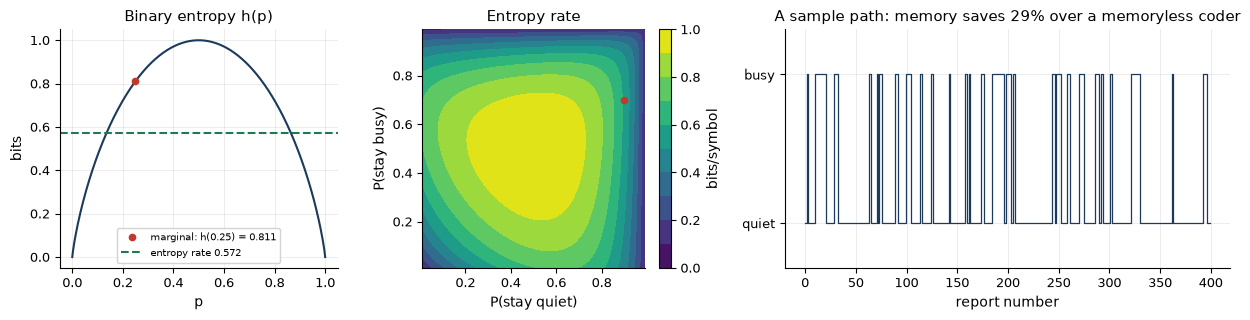

In [3]:
H_weather = it.entropy([1 / 2, 1 / 4, 1 / 8, 1 / 8])
P_sensor = np.array([[0.9, 0.1], [0.3, 0.7]])
lk.table([["weather station (1/2, 1/4, 1/8, 1/8)", H_weather],
          ["sensor: stationary distribution", str(np.round(it.markov_stationary(P_sensor), 3))],
          ["sensor: entropy of the marginal h(0.25)", float(it.hb(0.25))],
          ["sensor: entropy rate", it.markov_entropy_rate(P_sensor)]],
         ["quantity", "value"], fmt=".4g", title="Chapter 13 worked examples")

def markov_demo(stay0=0.9, stay1=0.7):
    P = np.array([[stay0, 1 - stay0], [1 - stay1, stay1]])
    pi = it.markov_stationary(P)
    Hm, Hr = float(it.hb(pi[1])), it.markov_entropy_rate(P)
    x = np.zeros(400, int)                                   # one sample path
    for n in range(1, len(x)):
        x[n] = rng.random() > P[x[n - 1], 0]
    f, ax = lk.fig((12.5, 3.3), 1, 3, gridspec_kw=dict(width_ratios=[1, 1, 1.6]))
    p = np.linspace(0, 1, 401)
    ax[0].plot(p, it.hb(p), color=lk.NAVY)
    ax[0].plot(pi[1], Hm, "o", color=lk.RED, label=f"marginal: h({pi[1]:.2f}) = {Hm:.3f}")
    ax[0].axhline(Hr, color=lk.GREEN, ls="--", label=f"entropy rate {Hr:.3f}")
    ax[0].set_xlabel("p"); ax[0].set_ylabel("bits"); ax[0].set_title("Binary entropy h(p)"); ax[0].legend(fontsize=7.5)
    s = np.linspace(0.01, 0.99, 99)
    S0, S1 = np.meshgrid(s, s)
    R = np.vectorize(lambda a, b: it.markov_entropy_rate([[a, 1 - a], [1 - b, b]]))(S0, S1)
    cs = ax[1].contourf(S0, S1, R, levels=np.linspace(0, 1, 11), cmap="viridis")
    ax[1].plot(stay0, stay1, "o", color=lk.RED); plt.colorbar(cs, ax=ax[1], label="bits/symbol")
    ax[1].set_xlabel("P(stay quiet)"); ax[1].set_ylabel("P(stay busy)"); ax[1].set_title("Entropy rate"); ax[1].grid(False)
    ax[2].step(np.arange(len(x)), x, where="post", color=lk.NAVY, lw=0.9)
    ax[2].set_ylim(-0.3, 1.3); ax[2].set_yticks([0, 1], ["quiet", "busy"]); ax[2].set_xlabel("report number")
    ax[2].set_title(f"A sample path: memory saves {100 * (1 - Hr / Hm):.0f}% over a memoryless coder")
    lk.show(f)

lk.interact(markov_demo, stay0=lk.slider(0.9, 0.01, 0.99, 0.01, "P(stay quiet)"),
            stay1=lk.slider(0.7, 0.01, 0.99, 0.01, "P(stay busy)"))

**What you should see.** 1.75 bits for the weather station and 0.572 bits per report for the sensor, a 30% saving
over the memoryless 0.811 bits. The contour map is 1 bit only along the line where the two "stay" probabilities sum
to one: that is the memoryless case, where knowing the last report tells you nothing. Long runs (both stay
probabilities near 1) have a low entropy rate even when the marginal is 50/50: that is why run-length coding works on fax pages.

### Try it yourself 1.1
The three-state chain of Problem 13.3 has rows $(0.8, 0.1, 0.1)$, $(0.2, 0.6, 0.2)$, $(0.25, 0.25, 0.5)$. What is its
entropy rate in bits per symbol? (Use `it.markov_entropy_rate`.)

In [5]:
answer_1_1 = None
P3 = [[0.8, 0.1, 0.1], [0.2, 0.6, 0.2], [0.25, 0.25, 0.5]]
lk.check("1.1 entropy rate of the three-state chain", answer_1_1, it.markov_entropy_rate(P3), atol=0.005)

[TODO] 1.1 entropy rate of the three-state chain: not attempted yet: replace the None with your answer

## 2. How much information is in English, and in a photograph?

Shannon estimated the entropy of English with a staircase of models: equiprobable letters ($\log_2 27 = 4.75$ bits),
single-letter frequencies ($F_1 \approx 4.0$), digrams ($\approx 3.3$), trigrams ($\approx 3.1$), and, with human
predictors, 0.6–1.3 bits per character for long passages. We repeat the staircase on about 35 000 characters of
Chapter 1 reduced to 27 symbols (a–z and space), in three ways:

* **plug-in conditional entropies** $H(X_n\mid X_{n-k}^{n-1})$ from $n$-gram counts (biased *low* once the number of
  contexts approaches the length of the text: the model memorises);
* an **adaptive order-$k$ context model**, the ideal code length of an arithmetic coder that learns as it goes
  (an honest, achievable rate);
* real **compressors** (DEFLATE/zlib, bzip2, LZMA) on the same text, in bits per character.

model,plug-in H (bits/char),adaptive coder (bits/char)
order 0,4.132,4.137
order 1,3.393,3.462
order 2,2.615,3.075
order 3,1.724,3.130
order 4,1.078,3.493


compressor,bits/char
zlib -9,3.000
bzip2,2.665
LZMA,2.858


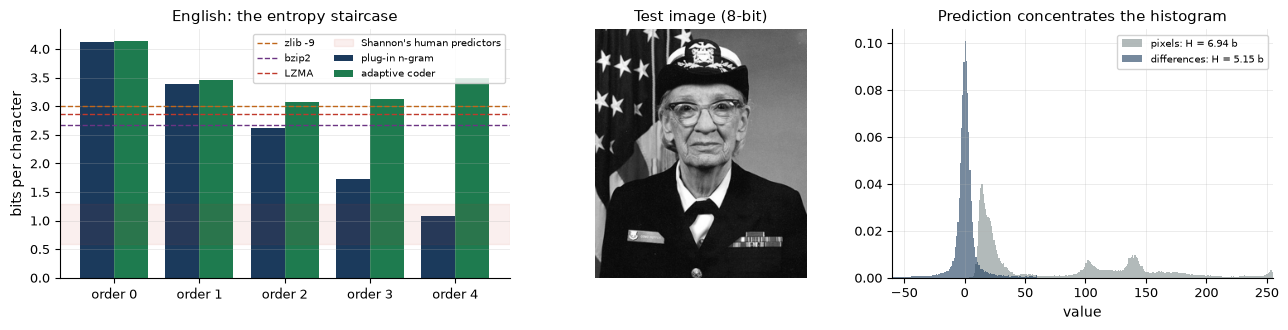

image model,bits/pixel
raw pixels (fixed length),8.00
pixel histogram entropy,6.94
left-neighbour residual entropy,5.15
planar-predictor residual entropy,5.06
DEFLATE on raw bytes (PNG-like),6.26


In [7]:
raw = open(os.path.join(DATA, "english_text.txt"), encoding="utf8").read().split("\n", 1)[1]
import re
text = re.sub(r" +", " ", re.sub(r"[^a-z ]", " ", raw.lower())).strip()
N = len(text)

def adaptive_bits(s, order, alpha=0.5):
    """Ideal code length (bits) of an adaptive order-k context model (add-alpha estimator)."""
    K = len(set(s)); cnt, tot, bits = {}, Counter(), 0.0
    for i, c in enumerate(s):
        ctx = s[max(0, i - order):i]
        d = cnt.setdefault(ctx, Counter())
        bits -= np.log2((d[c] + alpha) / (tot[ctx] + alpha * K))
        d[c] += 1; tot[ctx] += 1
    return bits

orders = [0, 1, 2, 3, 4]
plug = [it.ngram_entropy(text, k) for k in orders]
adap = [adaptive_bits(text, k) / N for k in orders]
comp = {name: 8 * len(fn(text.encode())) / N for name, fn in
        [("zlib -9", lambda b: zlib.compress(b, 9)), ("bzip2", bz2.compress), ("LZMA", lzma.compress)]}
rows = [[f"order {k}", p, a] for k, p, a in zip(orders, plug, adap)]
lk.table(rows, ["model", "plug-in H (bits/char)", "adaptive coder (bits/char)"], fmt=".3f",
         title=f"English, 27 symbols, {N:,} characters (log2 27 = {np.log2(27):.2f})")
lk.table([[k, v] for k, v in comp.items()], ["compressor", "bits/char"], fmt=".3f")

# --- a photograph: pixels, differences ---------------------------------------------------------
import matplotlib.cbook as cbook
from PIL import Image
img = np.asarray(Image.open(cbook.get_sample_data("grace_hopper.jpg")).convert("L").resize((256, 300))).astype(int)
h_pix = it.ngram_entropy(img.ravel().tolist(), 0)
dif = np.diff(img, axis=1, prepend=128)                      # left-neighbour prediction residual
h_dif = it.ngram_entropy(dif.ravel().tolist(), 0)
pred = np.zeros_like(img); pred[1:, 1:] = img[1:, :-1] + img[:-1, 1:] - img[:-1, :-1]   # planar predictor
h_pl = it.ngram_entropy((img - np.clip(pred, 0, 255))[1:, 1:].ravel().tolist(), 0)
h_png = 8 * len(zlib.compress(img.astype(np.uint8).tobytes(), 9)) / img.size

f, ax = lk.fig((13, 3.4), 1, 3, gridspec_kw=dict(width_ratios=[1.3, 0.8, 1.1]))
x = np.arange(len(orders))
ax[0].bar(x - 0.2, plug, 0.4, color=lk.NAVY, label="plug-in n-gram")
ax[0].bar(x + 0.2, adap, 0.4, color=lk.GREEN, label="adaptive coder")
for i, (k, v) in enumerate(comp.items()):
    ax[0].axhline(v, color=[lk.ORANGE, lk.PURPLE, lk.RED][i], ls="--", lw=1, label=k)
ax[0].axhspan(0.6, 1.3, color=lk.RED, alpha=0.08, label="Shannon's human predictors")
ax[0].set_xticks(x, [f"order {k}" for k in orders]); ax[0].set_ylabel("bits per character")
ax[0].set_title("English: the entropy staircase"); ax[0].legend(fontsize=7, ncol=2)
ax[1].imshow(img, cmap="gray"); ax[1].axis("off"); ax[1].set_title("Test image (8-bit)")
ax[2].hist(img.ravel(), 256, color=lk.GRAY, alpha=0.6, density=True, label=f"pixels: H = {h_pix:.2f} b")
ax[2].hist(dif.ravel(), np.arange(-60, 61), color=lk.NAVY, alpha=0.6, density=True, label=f"differences: H = {h_dif:.2f} b")
ax[2].set_xlim(-60, 255); ax[2].set_xlabel("value"); ax[2].legend(fontsize=7.5); ax[2].set_title("Prediction concentrates the histogram")
lk.show(f)
lk.table([["raw pixels (fixed length)", 8.0], ["pixel histogram entropy", h_pix], ["left-neighbour residual entropy", h_dif],
          ["planar-predictor residual entropy", h_pl], ["DEFLATE on raw bytes (PNG-like)", h_png]],
         ["image model", "bits/pixel"], fmt=".2f")

**What you should see.** The order-0 and order-1 plug-in values land near Shannon's 4.0 and 3.3 bits. Beyond order 2 the
plug-in estimate keeps falling (to well under 2 bits) because 35 000 characters cannot populate $27^4$ contexts: the
model memorises the text. The adaptive coder, which pays for learning every context it uses, turns around instead: its best
order is 2, at about 3.1 bits/char, and higher orders get *worse* on so little text. The general-purpose compressors reach
2.7–3.0 bits/char (bzip2 best) because they also exploit whole repeated words and phrases. All of these are far above
Shannon's 0.6–1.3: a human (or a large language model) brings knowledge that no 35 kB sample contains. On the image,
predicting each pixel from its neighbours drops the entropy from about 6.9 to about 5.1 bits per pixel: decorrelation is the
first step of every image coder (Chapter 16, Lab 24).

### Try it yourself 2.1
What is the *redundancy* $1 - H/\log_2 27$ of the text if you take $H$ to be the best adaptive-coder rate in the table?

In [9]:
answer_2_1 = None
lk.check("2.1 redundancy of the text (fraction)", answer_2_1, 1 - min(adap) / np.log2(27), atol=0.02)

[TODO] 2.1 redundancy of the text (fraction): not attempted yet: replace the None with your answer

## 3. Huffman codes and the source-coding bound

Any uniquely decodable code satisfies the Kraft inequality $\sum_i 2^{-\ell_i}\le 1$, and the best one has

$$H(X)\le \bar L_{\text{opt}} < H(X) + 1 .$$

Huffman's greedy algorithm (merge the two least probable nodes until one remains) achieves $\bar L_{\text{opt}}$. Coding
blocks of $n$ symbols divides the one-bit overhead by $n$. Below: the chapter's five-symbol example
(0.4, 0.2, 0.2, 0.1, 0.1: $\bar L = 2.2$ vs $H = 2.122$), then an interactive skewed source coded in blocks.

symbol,p,codeword,length
a,0.4,11,2
b,0.2,00,2
c,0.2,01,2
d,0.1,100,3
e,0.1,101,3


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

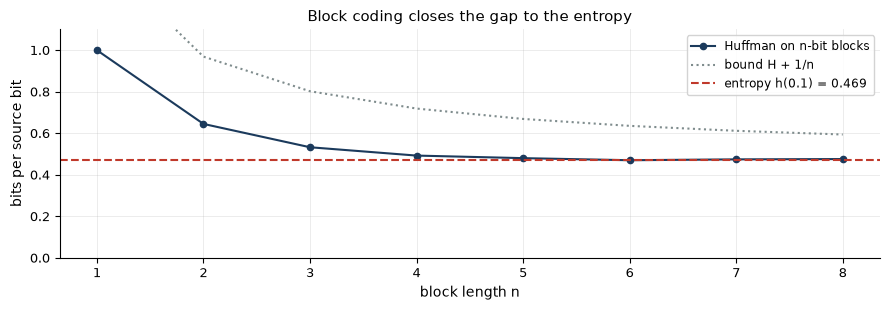

n,codewords,bits/source bit,excess over H
1,2,1.0000,0.5310
2,4,0.6450,0.1760
3,8,0.5327,0.0637
4,16,0.4925,0.0236
5,32,0.4802,0.0112
6,64,0.4702,0.0012
7,128,0.4743,0.0053
8,256,0.4758,0.0068


In [11]:
P5 = dict(a=0.4, b=0.2, c=0.2, d=0.1, e=0.1)
code5 = it.huffman_code(P5)
Lbar5 = sum(P5[s] * len(c) for s, c in code5.items())
lk.table([[s, P5[s], code5[s], len(code5[s])] for s in P5], ["symbol", "p", "codeword", "length"],
         title=f"Huffman: H = {it.entropy(list(P5.values())):.3f} bits, average length = {Lbar5:.2f} bits, "
               f"Kraft sum = {it.kraft_sum(map(len, code5.values())):.2f}")

def block_huffman(p1=0.1, nmax=8):
    """Binary source P(1) = p1, coded in blocks of n bits with a Huffman code on the 2^n blocks."""
    rows, Ls = [], []
    for n in range(1, nmax + 1):
        k = np.array([bin(i).count("1") for i in range(2 ** n)])
        probs = dict(enumerate(p1 ** k * (1 - p1) ** (n - k)))
        L = it.huffman_lengths(probs)
        Lb = sum(probs[s] * L[s] for s in probs) / n
        Ls.append(Lb); rows.append([n, 2 ** n, Lb, Lb - float(it.hb(p1))])
    f, ax = lk.fig((9, 3.2))
    ns = np.arange(1, nmax + 1)
    ax.plot(ns, Ls, "o-", color=lk.NAVY, label="Huffman on n-bit blocks")
    ax.plot(ns, it.hb(p1) + 1 / ns, ":", color=lk.GRAY, label="bound H + 1/n")
    ax.axhline(it.hb(p1), color=lk.RED, ls="--", label=f"entropy h({p1:g}) = {float(it.hb(p1)):.3f}")
    ax.set_xlabel("block length n"); ax.set_ylabel("bits per source bit"); ax.set_ylim(0, 1.1); ax.legend()
    ax.set_title("Block coding closes the gap to the entropy")
    lk.show(f)
    lk.table(rows, ["n", "codewords", "bits/source bit", "excess over H"], fmt={2: ".4f", 3: ".4f"})

lk.interact(block_huffman, p1=lk.slider(0.1, 0.01, 0.5, 0.01, "P(one)"), nmax=lk.islider(8, 2, 12, 1, "max block length"))

**What you should see.** A single-bit Huffman code can do no better than 1 bit per bit, however skewed the source.
With $P(1) = 0.1$ ($H = 0.469$), blocks of 8 bits get within a few hundredths of a bit of the entropy. The approach is
not monotone in $n$ (integer code lengths fit some block sizes better than others), but it always stays under $H + 1/n$.
Arithmetic coding (Lab 24) reaches the same limit without the exponential codebook.

### Try it yourself 3.1
The loaded die of Problem 13.1 shows 1 with probability ½ and each of 2–6 with probability 1/10. What is the average
length (bits) of a Huffman code for a single throw? (Build it with `it.huffman_code`.)

In [13]:
answer_3_1 = None
die = {1: 0.5, 2: 0.1, 3: 0.1, 4: 0.1, 5: 0.1, 6: 0.1}
lk.check("3.1 Huffman average length, loaded die", answer_3_1,
         sum(die[s] * len(c) for s, c in it.huffman_code(die).items()), atol=0.01)

[TODO] 3.1 Huffman average length, loaded die: not attempted yet: replace the None with your answer

## 4. Discrete channels: BSC, BEC, Z and Blahut–Arimoto

The capacity of a discrete memoryless channel $W(y\mid x)$ is $C = \max_{p(x)} I(X;Y)$. Symmetric channels are
maximised by a uniform input: $C_{\text{BSC}} = 1 - h(p)$, $C_{\text{BEC}} = 1 - \epsilon$. Asymmetric ones are not:
the Z-channel's best input sends *fewer* ones. For any channel, the **Blahut–Arimoto** iteration

$$D_x = D\big(W(\cdot\mid x)\,\|\,q\big),\quad q = pW,\qquad p_x \leftarrow p_x 2^{D_x}/\textstyle\sum_{x'} p_{x'}2^{D_{x'}}$$

converges to capacity, sandwiched between $I(p^{(t)})$ below and $\max_x D_x$ above.

The chapter's worked example: BPSK at $E_s/N_0 = 0$ dB with a hard slicer is a BSC with $p = Q(\sqrt2) = 0.0786$ and
$C = 0.603$; given the soft outputs instead, the binary-input AWGN channel has $C = 0.72$.

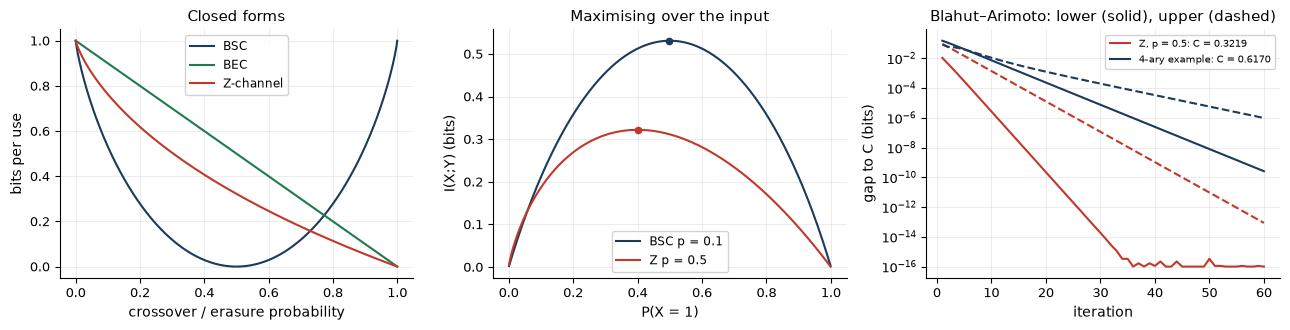

channel,capacity (bits/use),note
Z-channel p = 0.5,0.3219,0.3219
4-ary example,0.6170,p* = [0.398 0.146 0.456 0. ]
"BPSK 0 dB, hard decisions (BSC)",0.6026,p = 0.0786
"BPSK 0 dB, soft decisions (BI-AWGN)",0.7215,


In [15]:
W4 = np.array([[.7, .2, .1, 0], [.1, .7, .1, .1], [0, .2, .6, .2], [.25, .25, .25, .25]])
Wz = np.array([[1.0, 0.0], [0.5, 0.5]])
f, ax = lk.fig((13, 3.4), 1, 3)
p = np.linspace(1e-6, 1 - 1e-6, 500)
ax[0].plot(p, it.bsc_capacity(p), label="BSC", color=lk.NAVY)
ax[0].plot(p, it.bec_capacity(p), label="BEC", color=lk.GREEN)
ax[0].plot(p, it.z_capacity(p), label="Z-channel", color=lk.RED)
ax[0].set_xlabel("crossover / erasure probability"); ax[0].set_ylabel("bits per use"); ax[0].legend(); ax[0].set_title("Closed forms")
q = np.linspace(0.001, 0.999, 400)
for W, lab, col in [(np.array([[.9, .1], [.1, .9]]), "BSC p = 0.1", lk.NAVY), (Wz, "Z p = 0.5", lk.RED)]:
    I = [it.dmc_mutual_info([1 - a, a], W) for a in q]
    ax[1].plot(q, I, color=col, label=lab); ax[1].plot(q[np.argmax(I)], max(I), "o", color=col)
ax[1].set_xlabel("P(X = 1)"); ax[1].set_ylabel("I(X;Y) (bits)"); ax[1].legend(); ax[1].set_title("Maximising over the input")
for W, lab, col in [(Wz, "Z, p = 0.5", lk.RED), (W4, "4-ary example", lk.NAVY)]:
    C, popt, lo, up = it.blahut_arimoto(W, iters=60, tol=0)
    Cinf = it.blahut_arimoto(W, iters=5000)[0]
    t = np.arange(1, len(lo) + 1)
    ax[2].semilogy(t, np.maximum(Cinf - lo, 1e-16), color=col, label=f"{lab}: C = {Cinf:.4f}")
    ax[2].semilogy(t, np.maximum(up - Cinf, 1e-16), "--", color=col)
ax[2].set_xlabel("iteration"); ax[2].set_ylabel("gap to C (bits)"); ax[2].legend(fontsize=7.5)
ax[2].set_title("Blahut–Arimoto: lower (solid), upper (dashed)")
lk.show(f)
C4, p4, _, _ = it.blahut_arimoto(W4, 5000)
p_hard = norm.sf(np.sqrt(2))
lk.table([["Z-channel p = 0.5", it.blahut_arimoto(Wz, 5000)[0], float(it.z_capacity(0.5))],
          ["4-ary example", C4, "p* = " + str(np.round(p4, 3))],
          ["BPSK 0 dB, hard decisions (BSC)", float(it.bsc_capacity(p_hard)), f"p = {p_hard:.4f}"],
          ["BPSK 0 dB, soft decisions (BI-AWGN)", it.biawgn_capacity(1.0), ""]],
         ["channel", "capacity (bits/use)", "note"], fmt={1: ".4f"})

**What you should see.** The Z-channel with $p = 0.5$ has $C = \log_2 1.25 = 0.322$ bits, reached with only about 40% ones.
The 4-ary example puts (almost) zero probability on its fourth input, which is useless (every output equally likely).
Blahut–Arimoto's gap shrinks geometrically, and the upper bound tells you when to stop without knowing $C$.
The hard slicer throws away 16% of the capacity at 0 dB: that is the "2 dB of soft decisions" of Chapter 14.

### Try it yourself 4.1
Build the binary **erasure-plus-error** channel with outputs {0, e, 1}: each input is erased with probability 0.1 and
flipped with probability 0.05 (and received correctly otherwise). What is its capacity? (Write `W` and use `it.blahut_arimoto`.)

In [17]:
answer_4_1 = None
lk.check("4.1 capacity of the binary error-and-erasure channel", answer_4_1,
         it.blahut_arimoto(np.array([[0.85, 0.10, 0.05], [0.05, 0.10, 0.85]]), 2000)[0], atol=0.002)

[TODO] 4.1 capacity of the binary error-and-erasure channel: not attempted yet: replace the None with your answer

## 5. The Gaussian channel: Shannon, constrained-input and BICM capacity

With Gaussian inputs the complex AWGN channel carries $C = \log_2(1 + E_s/N_0)$ bits per symbol. A real transmitter uses a
finite constellation, which caps the rate at $\log_2 M$ and costs SNR even below the cap: the **coded-modulation (CM)**
capacity $I(X;Y)$ with uniform inputs on the constellation. Square QAM is two independent PAMs, so `it.qam_cm` computes
it exactly by Gauss–Hermite quadrature; other constellations (8-PSK, APSK) use Monte Carlo (`it.mi_2d_mc`). At high rate
the gap of a uniform square grid tends to the **shaping gap** $\pi e/6 = 1.53$ dB.

Practical receivers decode bit by bit (**BICM**: per-bit LLRs, one binary code): the capacity becomes the sum of the
bit-channel capacities. With Gray labels the loss is tiny; with natural labels it is not.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

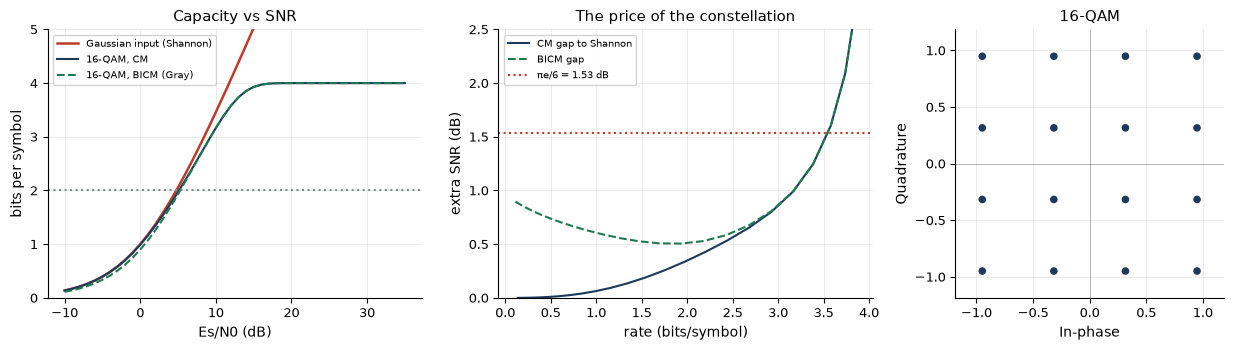

input,Es/N0 for 2 b/sym (dB)
Shannon (Gaussian input),4.77
16-QAM CM,5.12
16-QAM BICM,5.28


In [19]:
def gaussian_demo(constellation="16qam", rate=2.0):
    con = cl.get_constellation(constellation)
    sd = np.linspace(-10, 35, 46)
    g = lk.undb(sd)
    square = "qam" in constellation or constellation == "qpsk"
    if square:
        cm = np.array([it.qam_cm(con.M, x) for x in g])
        bi = np.array([it.qam_bicm(con.M, x) for x in g])
    else:
        cm = np.array([it.mi_2d_mc(con, x, n=8000, rng=np.random.default_rng(1)) for x in g])
        bi = None
    f, ax = lk.fig((12.5, 3.6), 1, 3, gridspec_kw=dict(width_ratios=[1.2, 1.2, 0.9]))
    ax[0].plot(sd, np.log2(1 + g), color=lk.RED, lw=1.8, label="Gaussian input (Shannon)")
    ax[0].plot(sd, cm, color=lk.NAVY, label=f"{con.name}, CM")
    if bi is not None:
        ax[0].plot(sd, bi, "--", color=lk.GREEN, label=f"{con.name}, BICM (Gray)")
    ax[0].axhline(rate, color=lk.GRAY, ls=":")
    ax[0].set_xlabel("Es/N0 (dB)"); ax[0].set_ylabel("bits per symbol"); ax[0].legend(fontsize=7.5)
    ax[0].set_ylim(0, con.k + 1); ax[0].set_title("Capacity vs SNR")
    ok = (cm > 0.05) & (cm < 0.97 * con.k)
    ax[1].plot(cm[ok], sd[ok] - lk.db(2 ** cm[ok] - 1), color=lk.NAVY, label="CM gap to Shannon")
    if bi is not None:
        okb = (bi > 0.05) & (bi < 0.97 * con.k)
        ax[1].plot(bi[okb], sd[okb] - lk.db(2 ** bi[okb] - 1), "--", color=lk.GREEN, label="BICM gap")
    ax[1].axhline(lk.db(np.pi * np.e / 6), color=lk.RED, ls=":", label="πe/6 = 1.53 dB")
    ax[1].set_xlabel("rate (bits/symbol)"); ax[1].set_ylabel("extra SNR (dB)"); ax[1].set_ylim(0, 2.5); ax[1].legend(fontsize=7.5)
    ax[1].set_title("The price of the constellation")
    lk.constellation(ax[2], con.points, None, con.name, s=30, alpha=1)
    lk.show(f)
    if rate < con.k:
        s_cm = np.interp(rate, cm, sd)
        rows = [["Shannon (Gaussian input)", lk.db(2 ** rate - 1)], [f"{con.name} CM", s_cm]]
        if bi is not None:
            rows.append([f"{con.name} BICM", np.interp(rate, bi, sd)])
        lk.table(rows, ["input", f"Es/N0 for {rate:g} b/sym (dB)"], fmt=".2f")

lk.interact(gaussian_demo, constellation=lk.choice(["qpsk", "16qam", "64qam", "256qam", "8psk", "16psk"], "16qam", "constellation"),
            rate=lk.slider(2.0, 0.5, 7.5, 0.25, "target rate (b/symbol)"))

constellation,rate (b/sym),CM: Es/N0 needed (dB),Shannon (dB)
4-QAM,1,0.19,0.00
16-QAM,1,0.06,0.00
16-QAM,2,5.12,4.77
16-QAM,3,9.30,8.45
64-QAM,1,0.05,0.00
64-QAM,2,5.03,4.77
64-QAM,3,9.01,8.45
64-QAM,4,12.62,11.76
256-QAM,1,0.05,0.00
256-QAM,2,5.01,4.77


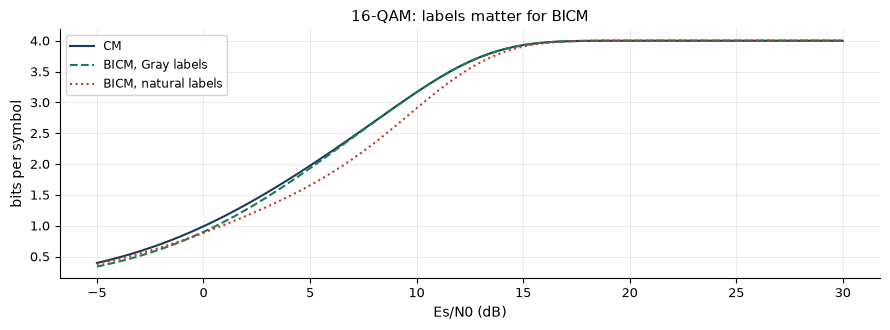

In [20]:
# BICM with natural labels, and the chapter's table of required SNRs
sd = np.linspace(-5, 30, 71); g = lk.undb(sd)
cm16 = np.array([it.qam_cm(16, x) for x in g])
gray16 = np.array([it.qam_bicm(16, x) for x in g])
nat16 = np.array([it.qam_bicm(16, x, natural=True) for x in g])
rows = []
for M in [4, 16, 64, 256]:
    for R in [1, 2, 3, 4, 6]:
        if R < np.log2(M):
            rows.append([f"{M}-QAM", R, brentq(lambda s: it.qam_cm(M, lk.undb(s)) - R, -15, 45), lk.db(2 ** R - 1)])
lk.table(rows, ["constellation", "rate (b/sym)", "CM: Es/N0 needed (dB)", "Shannon (dB)"], fmt={2: ".2f", 3: ".2f"})
f, ax = lk.fig("wide")
for y, lab, col, ls in [(cm16, "CM", lk.NAVY, "-"), (gray16, "BICM, Gray labels", lk.GREEN, "--"),
                        (nat16, "BICM, natural labels", lk.RED, ":")]:
    ax.plot(sd, y, ls, color=col, label=lab)
ax.set_xlabel("Es/N0 (dB)"); ax.set_ylabel("bits per symbol"); ax.legend(); ax.set_title("16-QAM: labels matter for BICM")
lk.show(f)

**What you should see.** At 2 b/symbol 16-QAM needs about 5.1 dB against Shannon's 4.77 dB; 64-QAM at 4 bits needs
about 12.6 dB against 11.76; the gap climbs towards (but never quite reaches, at finite rate) 1.53 dB. A denser
constellation used below its cap costs less (256-QAM at 2 b/sym is within 0.25 dB). Gray BICM stays within roughly
0.1–0.2 dB of CM at the rates where the constellation is normally used, while natural labelling loses up to about 1 dB:
this is why every modern standard (DVB-S2, Wi-Fi, LTE, NR) uses Gray-labelled BICM.

### Try it yourself 5.1
What $E_s/N_0$ (dB) does 64-QAM coded modulation need for 5 bits per symbol? (Use `brentq` on `it.qam_cm` as in the
table cell.)

In [22]:
answer_5_1 = None
lk.check("5.1 64-QAM CM Es/N0 for 5 b/sym (dB)", answer_5_1, brentq(lambda s: it.qam_cm(64, lk.undb(s)) - 5, 0, 40), atol=0.1)

[TODO] 5.1 64-QAM CM Es/N0 for 5 b/sym (dB): not attempted yet: replace the None with your answer

## 6. Short packets: the finite-blocklength penalty

Capacity is an asymptote in block length. At block length $n$ (real channel uses) and block-error probability
$\epsilon$, the Polyanskiy–Poor–Verdú **normal approximation** gives the best achievable rate

$$R^*(n,\epsilon)\approx C - \sqrt{\frac{V}{n}}\,Q^{-1}(\epsilon) + \frac{\log_2 n}{2n},\qquad
V = \frac{\mathrm{SNR}(\mathrm{SNR}+2)}{2(\mathrm{SNR}+1)^2}\log_2^2 e .$$

The chapter's URLLC example: 256 information bits (a 32-byte packet) at $\epsilon = 10^{-5}$ in $n = 512$ real uses
needs about 1.8 dB more than Shannon's 0 dB.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

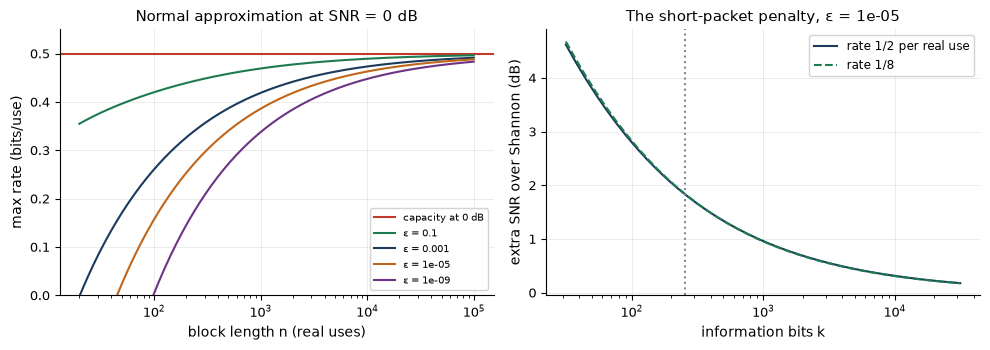

n (real uses),rate,Shannon Eb/N0 (dB),normal approx. Eb/N0 (dB),penalty (dB)
320,0.800,1.04,2.91,1.88
512,0.500,0.00,1.83,1.83
1024,0.250,-0.82,1.00,1.82
2048,0.125,-1.21,0.62,1.84


In [24]:
def fbl_demo(k_bits=256, eps_exp=-5):
    eps = 10.0 ** eps_exp
    n = np.logspace(np.log10(20), 5, 200)
    f, ax = lk.fig("row2", 1, 2)
    ax[0].axhline(0.5, color=lk.RED, label="capacity at 0 dB")
    for e, col in [(1e-1, lk.GREEN), (1e-3, lk.NAVY), (1e-5, lk.ORANGE), (1e-9, lk.PURPLE)]:
        ax[0].semilogx(n, it.normal_approx_awgn(n, 1.0, e), color=col, label=f"ε = {e:g}")
    ax[0].set_ylim(0, 0.55); ax[0].set_xlabel("block length n (real uses)"); ax[0].set_ylabel("max rate (bits/use)")
    ax[0].legend(fontsize=7.5); ax[0].set_title("Normal approximation at SNR = 0 dB")
    rows = []
    for n_ in [k_bits * m for m in (1.25, 2, 4, 8)]:
        R = k_bits / n_
        P = brentq(lambda P: it.normal_approx_awgn(n_, P, eps) - R, 2 ** (2 * R) - 1, 1e6)
        ebn0 = lk.db(P / (2 * R)); eb_sh = lk.db((2 ** (2 * R) - 1) / (2 * R))
        rows.append([int(n_), R, eb_sh, ebn0, ebn0 - eb_sh])
    ks = np.logspace(1.5, 4.5, 40)
    ax[1].semilogx(ks, [it.fbl_snr_penalty_db(2 * k, 0.5, eps) for k in ks], color=lk.NAVY, label="rate 1/2 per real use")
    ax[1].semilogx(ks, [it.fbl_snr_penalty_db(8 * k, 0.125, eps) for k in ks], "--", color=lk.GREEN, label="rate 1/8")
    ax[1].axvline(k_bits, color=lk.GRAY, ls=":")
    ax[1].set_xlabel("information bits k"); ax[1].set_ylabel("extra SNR over Shannon (dB)"); ax[1].legend()
    ax[1].set_title(f"The short-packet penalty, ε = {eps:g}")
    lk.show(f)
    lk.table(rows, ["n (real uses)", "rate", "Shannon Eb/N0 (dB)", "normal approx. Eb/N0 (dB)", "penalty (dB)"],
             fmt={1: ".3f", 2: ".2f", 3: ".2f", 4: ".2f"}, title=f"{k_bits} information bits at ε = {eps:g}")

lk.interact(fbl_demo, k_bits=lk.islider(256, 32, 8192, 32, "information bits"), eps_exp=lk.islider(-5, -9, -1, 1, "log10 ε"))

**What you should see.** For 256 bits at $\epsilon=10^{-5}$ the penalty is about 1.8 dB whether the code rate is 0.8 or 1/8:
it is set by the number of information bits and the reliability target, not by the bandwidth. It falls roughly as
$1/\sqrt{k}$: 0.6 dB at a few thousand bits, which is why bulk-data links sit much closer to capacity than control channels.

### Try it yourself 6.1
Using `it.fbl_snr_penalty_db`, what is the penalty (dB) for $k = 1024$ bits at rate ½ per real use ($n = 2048$) and $\epsilon = 10^{-5}$?

In [26]:
answer_6_1 = None
lk.check("6.1 penalty for 1024 bits, n = 2048, eps = 1e-5 (dB)", answer_6_1, it.fbl_snr_penalty_db(2048, 0.5, 1e-5), atol=0.05)

[TODO] 6.1 penalty for 1024 bits, n = 2048, eps = 1e-5 (dB): not attempted yet: replace the None with your answer

## 7. Water-filling and bit loading

With $K$ parallel Gaussian subchannels of gains $|H_k|^2$ and noises $N_k$ (the tones of OFDM or DSL), and a total power
$P$, the capacity-maximising allocation is **water-filling**: $P_k = (\mu - N_k/|H_k|^2)^+$ with the water level $\mu$ set so
that $\sum P_k = P$. Practical modems quantise it with the **SNR gap**: tone $k$ carries
$b_k = \lfloor\log_2(1 + \mathrm{SNR}_k/\Gamma)\rfloor$ bits, with $\Gamma \approx 9.8$ dB (uncoded QAM at $10^{-7}$) minus
the coding gain plus the margin.

Design your own channel: a DSL-like loop whose loss grows with $\sqrt f$, a narrowband interferer (AM radio ingress), and a
flat transmit PSD budget.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

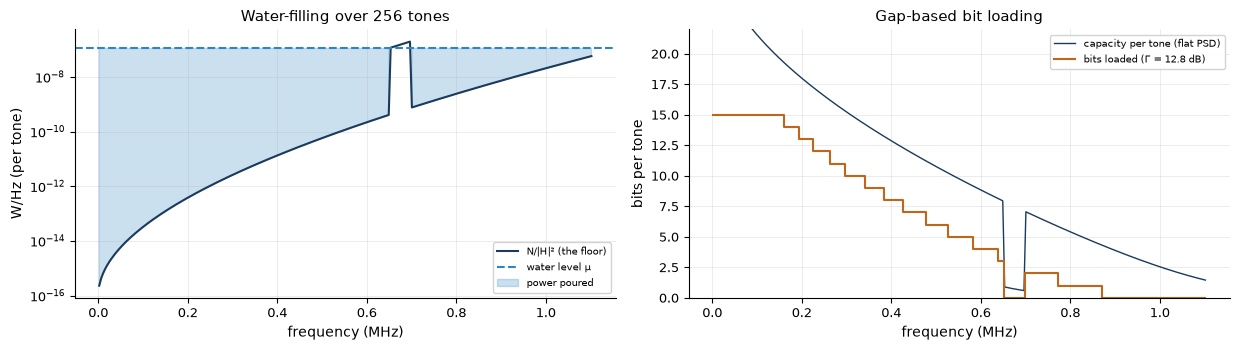

,Mb/s (or count)
"capacity, flat PSD",10.86
"capacity, water-filling",10.89
gap-loaded integer bits,6.23
tones in use (bits > 0),191


In [28]:
def waterfill_demo(loop_db=78.0, ingress_db=25.0, psd_dbm_hz=-40.0, gap_db=12.8):
    K, df = 256, 4312.5
    fr = (np.arange(K) + 0.5) * df
    att = 10 + loop_db * np.sqrt(fr / 1e6) + 4 * fr / 1e6
    Hg = lk.undb(-att)
    N = lk.undb(-140 - 30) * np.ones(K)
    N[(fr > 650e3) & (fr < 700e3)] *= lk.undb(ingress_db)
    N = N + lk.undb(-150 - 30) * (fr / 1e6) ** 1.5 * 3
    Psd = lk.undb(psd_dbm_hz - 30)
    pw, mu = it.waterfill(N / Hg, Psd * K)
    snr_flat, snr_wf = Psd * Hg / N, pw * Hg / N
    b = it.gap_bit_loading(snr_flat, gap_db)
    sym_rate = 4000
    f, ax = lk.fig((12.5, 3.6), 1, 2)
    ax[0].semilogy(fr / 1e6, N / Hg, color=lk.NAVY, label="N/|H|² (the floor)")
    ax[0].axhline(mu, color=lk.BLUE, ls="--", label="water level μ")
    ax[0].fill_between(fr / 1e6, N / Hg, np.maximum(N / Hg, mu), where=pw > 0, color=lk.BLUE, alpha=0.25, label="power poured")
    ax[0].set_xlabel("frequency (MHz)"); ax[0].set_ylabel("W/Hz (per tone)"); ax[0].legend(fontsize=7.5)
    ax[0].set_title("Water-filling over 256 tones")
    ax[1].plot(fr / 1e6, np.log2(1 + snr_flat), color=lk.NAVY, lw=1, label="capacity per tone (flat PSD)")
    ax[1].step(fr / 1e6, b, where="mid", color=lk.ORANGE, label=f"bits loaded (Γ = {gap_db:.1f} dB)")
    ax[1].set_xlabel("frequency (MHz)"); ax[1].set_ylabel("bits per tone"); ax[1].legend(fontsize=7.5)
    ax[1].set_title("Gap-based bit loading"); ax[1].set_ylim(0, 22)
    lk.show(f)
    lk.table([["capacity, flat PSD", np.sum(np.log2(1 + snr_flat)) * sym_rate / 1e6],
              ["capacity, water-filling", np.sum(np.log2(1 + snr_wf)) * sym_rate / 1e6],
              ["gap-loaded integer bits", np.sum(b) * sym_rate / 1e6],
              ["tones in use (bits > 0)", int(np.sum(b > 0))]], ["", "Mb/s (or count)"], fmt=".2f")

lk.interact(waterfill_demo, loop_db=lk.slider(78, 20, 120, 2, "loop loss coefficient (dB/√MHz)"),
            ingress_db=lk.slider(25, 0, 50, 1, "AM ingress (dB)"),
            psd_dbm_hz=lk.slider(-40, -60, -30, 1, "TX PSD (dBm/Hz)"), gap_db=lk.slider(12.8, 0, 20, 0.2, "gap Γ (dB)"))

**What you should see.** At a high SNR, water-filling is barely better than a flat PSD (well under 1%): capacity is
insensitive to the power allocation, which is why DSL uses a flat mask and lets *bit loading* do the work. Raise the loop
loss: the upper tones fall below the water level and are switched off, and only then does water-filling help noticeably.
The integer gap-loaded rate sits a few Mb/s below capacity: $\Gamma$ = 12.8 dB is 9.8 dB for uncoded QAM, minus 3 dB of
coding gain, plus a 6 dB margin.

### Try it yourself 7.1
Four subchannels have noise-to-gain ratios 0.1, 0.2, 0.5 and 1.0, and the total power is 1. What is the water level $\mu$?

In [30]:
answer_7_1 = None
lk.check("7.1 water level", answer_7_1, it.waterfill(np.array([0.1, 0.2, 0.5, 1.0]), 1.0)[1], atol=0.005)

[TODO] 7.1 water level: not attempted yet: replace the None with your answer

## Key takeaways
* Entropy is the floor for lossless compression; memory (entropy rate) and context are where real compressors find their gains.
* Huffman codes sit within one bit of $H$; blocks or arithmetic coding close the gap.
* Capacity is a maximum over inputs; Blahut–Arimoto finds it for any DMC. Hard decisions cost about 16% at 0 dB.
* Finite constellations cost SNR (up to 1.53 dB of shaping gap); Gray-labelled BICM costs almost nothing more.
* Short packets pay a penalty of order $\sqrt{V/n}\,Q^{-1}(\epsilon)$: ~1.8 dB for a 32-byte, $10^{-5}$ URLLC packet.
* Water-filling matters at low SNR; at high SNR, gap-based bit loading with a flat PSD is near-optimal.

## Going further (hardware: USRP B200 / GNU Radio)
* Capture a few seconds of a real signal with `gnuradio/gr01_spectrum_iq_capture.py` and compute the entropy of the 8-bit
  or 16-bit samples with `it.ngram_entropy`: noise-like signals are nearly incompressible, while a captured tone is not.
* Run `gr04_ofdm_link.py --sim --multipath` and record the per-subcarrier SNR from the channel estimate; feed it to
  `it.gap_bit_loading` and compare the rate you could load with the fixed-MCS rate of the flowgraph.

## Exercises
1. **(Warm-up)** Plot $I(X;Y)$ of the BSC with $p = 0.1$ as a function of $P(X=1)$ and confirm the maximum is at ½.
2. **(Core)** Compute the CM capacity of the DVB-S2 16-APSK (4+12) constellation with `it.mi_2d_mc` and compare it with
   16-QAM. At which rates is APSK better? (Use `commlib.satellite.dvbs2_16apsk`.)
3. **(Core)** Implement the ergodic and outage capacity of Rayleigh fading (`it.rayleigh_ergodic_capacity`,
   `it.rayleigh_outage_capacity`) and reproduce the 20 dB values quoted in Chapter 13.
4. **(Stretch)** Implement Lloyd–Max quantisation of a Gaussian source and plot its SNR against the rate-distortion bound
   $6.02R$ dB; then add entropy coding of a uniform quantiser and find the 1.53 dB gap again.

In [32]:
lk.summary()

[good] Lab 19 finished in 4.3 s. Self-checks: 0 passed, 0 failed, 7 still to do.